In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
problems = ["reacher", "inverted_double_pendulum"] #, "hopper", "walker2d", "swimmer", "halfcheetah"]
seeds = range(5)
algorithms = ["ga", "gomea"]
solvers = ["cgp"]

dfs = []
for solver in solvers:
    for algorithm in algorithms:
        for problem in problems:
            for seed in seeds:
                if algorithm == "gomea":
                    for fos in ["U", "RT", "LT", "N1", "N2"]:
                        tmp_df = pd.read_csv(
                            f"../results/{algorithm}_{solver}_{problem}_{fos}_{seed}_fi.csv")
                        tmp_df["seed"] = seed
                        tmp_df["algorithm"] = f"{algorithm}_{fos}"
                        tmp_df["problem"] = problem
                        tmp_df["solver"] = solver
                        dfs.append(tmp_df)
                else:
                    tmp_df = pd.read_csv(f"../results/{algorithm}_{solver}_{problem}_{seed}.csv")
                    tmp_df["seed"] = seed
                    tmp_df["algorithm"] = algorithm
                    tmp_df["problem"] = problem
                    tmp_df["solver"] = solver
                    dfs.append(tmp_df)
control_df = pd.concat(dfs, ignore_index=True)
control_df.head()

,evaluation,fitness,time,seed,algorithm,problem,solver
0,100,-151.784012,35.09,0,ga,reacher,cgp
1,200,-156.280396,5.15,0,ga,reacher,cgp
2,300,-152.477829,5.13,0,ga,reacher,cgp
3,400,-112.733208,5.12,0,ga,reacher,cgp
4,500,-131.332565,5.13,0,ga,reacher,cgp


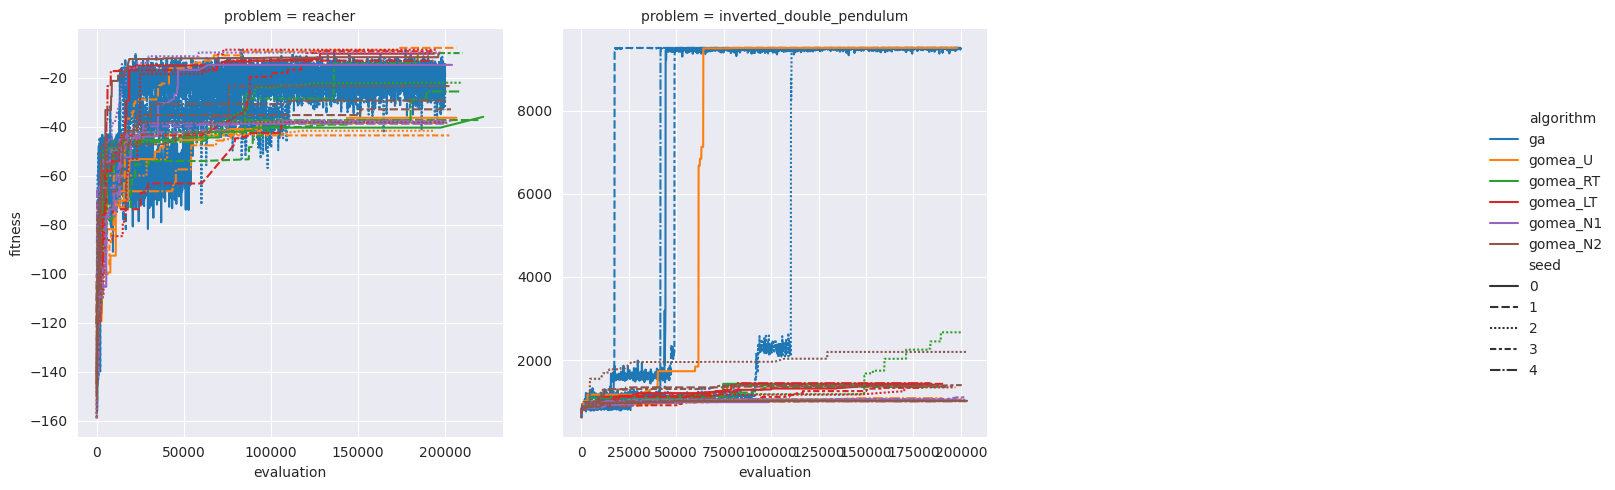

In [3]:
# agg_df = (
#     control_df
#     .groupby(["evaluation", "problem", "algorithm", "solver"])
#     .mean()
#     .reset_index()
# )
sns.relplot(
    # agg_df,
    control_df,
    style="seed",
    x="evaluation",
    y="fitness",
    col="problem",
    col_wrap=3,
    hue="algorithm",
    kind="line",
    facet_kws={'sharey': False, 'sharex': False}
)
plt.show()

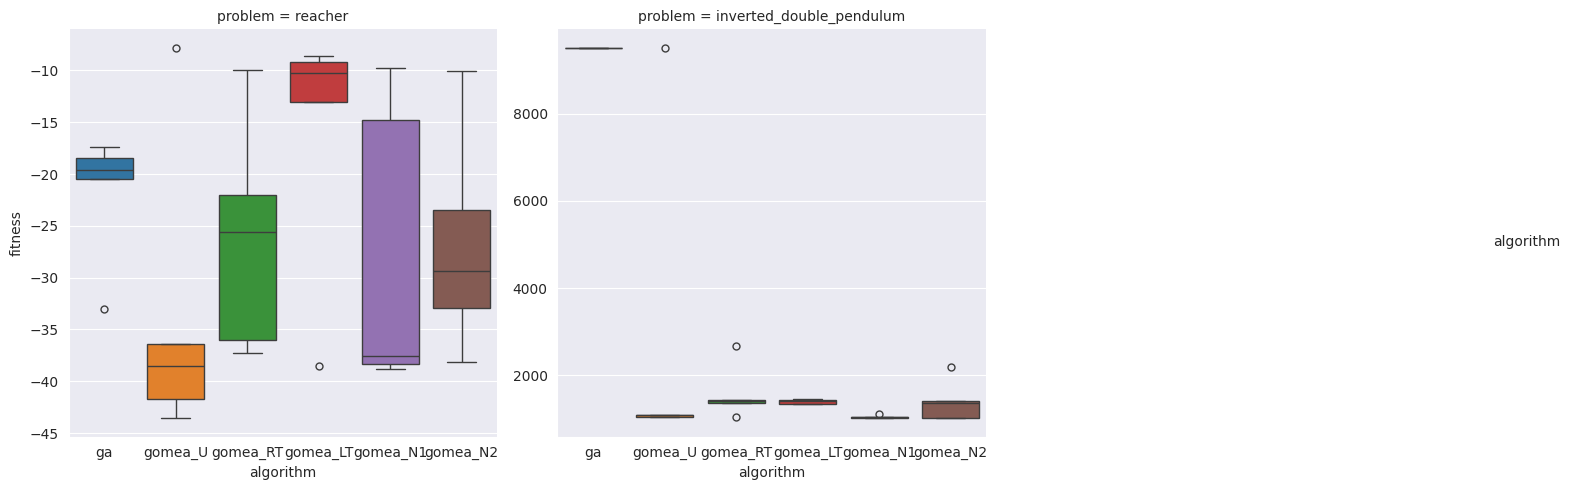

In [5]:
control_df["max_eval"] = control_df.groupby(["algorithm", "problem", "seed"])["evaluation"].transform("max")
final_control_df = control_df[control_df["evaluation"] == control_df["max_eval"]].drop(columns="max_eval")
sns.catplot(
    data=final_control_df, x='algorithm', y='fitness', hue="algorithm",
    col='problem', kind='box', col_wrap=3,
    sharey=False
)
plt.show()